# 데이터 및 라이브러리 로드

In [1]:
import pandas as pd
import warnings
import numpy as np
import ast

import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # 모든 컬럼이 다 보인다.
pd.set_option('display.max_rows', 100) # 행 출력 개수 제한

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

# 컬럼 너비 제한을 해제
pd.set_option('display.max_colwidth', None)
# 컬럼 너비 설정 초기화
# pd.reset_option('display.max_colwidth')

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
portfolio = pd.read_csv('../data/portfolio.csv')
profile = pd.read_csv('../data/profile.csv')
transcript = pd.read_csv('../data/transcript.csv')

## 데이터 체크

In [3]:
print("[Shape]")
print("-" * 80)
print(f"portfolio : {portfolio.shape}, profile : {profile.shape}, transcript : {transcript.shape}")

print()
print("="*80)

print("\n[Info]")
print("-" * 80)
print("[portfolio]")
print(f"{portfolio.info()}")
print("\n[profile]")
print(f"{profile.info()}")
print("\n[transcript]")
print(f"{transcript.info()}")

print()
print("="*80)

print("\n[Describe]")
print("-" * 80)
print("[portfolio]")
print(f"{portfolio.describe()}")
print("\n[profile]")
print(f"{profile.describe()}")
print("\n[transcript]")
print(f"{transcript.describe()}")


[Shape]
--------------------------------------------------------------------------------
portfolio : (10, 7), profile : (17000, 6), transcript : (306534, 5)


[Info]
--------------------------------------------------------------------------------
[portfolio]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10 non-null     int64 
 1   reward      10 non-null     int64 
 2   channels    10 non-null     object
 3   difficulty  10 non-null     int64 
 4   duration    10 non-null     int64 
 5   offer_type  10 non-null     object
 6   id          10 non-null     object
dtypes: int64(4), object(3)
memory usage: 692.0+ bytes
None

[profile]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Un

In [4]:
print("[Head]")
print("-" * 80)
print("[portfolio]")
display(portfolio.head())
print("[profile]")
display(profile.head())
print("[transcript]")
display(transcript.head())

[Head]
--------------------------------------------------------------------------------
[portfolio]


,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


[profile]


,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


[transcript]


,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [5]:
# 범주형 데이터 확인

# portfolio 테이블
print("[portfolio 테이블]")
print(f"{portfolio['channels'].value_counts()}")
# ['web', 'email', 'mobile', 'social']    4
# ['web', 'email', 'mobile']              3
# ['email', 'mobile', 'social']           2
# ['web', 'email']                        1
print("-"*80)

print(f"{portfolio['offer_type'].value_counts().sort_index()}")
# bogo             4
# discount         4
# informational    2
print("="*80)


# profile 테이블
print("\n[profile 테이블]")
print(f"{profile['gender'].value_counts().sort_index()}")
# F    6129
# M    8484
# O     212
print("="*80)

# transcript 테이블
print("\n[transcript 테이블]")
print(f"{transcript['event'].value_counts().sort_index()}")

[portfolio 테이블]
channels
['web', 'email', 'mobile', 'social']    4
['web', 'email', 'mobile']              3
['email', 'mobile', 'social']           2
['web', 'email']                        1
Name: count, dtype: int64
--------------------------------------------------------------------------------
offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64

[profile 테이블]
gender
F    6129
M    8484
O     212
Name: count, dtype: int64

[transcript 테이블]
event
offer completed     33579
offer received      76277
offer viewed        57725
transaction        138953
Name: count, dtype: int64


In [6]:
# informational? 정보제공?이 이상해서 확인해봄
portfolio[portfolio['offer_type']=='informational']
# offer_type이 informational일때, difficulty와 reward가 0임을 확인. 단순 정보 제공이 맞는듯.

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
7,7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837


### 중복값 확인

In [7]:
# 중복값 확인

print("[중복값 확인]")
print("portfolio id 개수")
print(f"{portfolio['id'].nunique()}") 
# 10 -> 고유함.

print("profile id 개수")
print(f"{profile['id'].nunique()}") 
# 17000 -> 고유함

print("transcript person 개수")
print(f"{transcript['person'].nunique()}")
# 17000 -> 중복값 o

[중복값 확인]
portfolio id 개수
10
profile id 개수
17000
transcript person 개수
17000


### 결측치 확인

In [8]:
#portfolio
print("[portfolio 테이블]")
print(f"reward : {portfolio['reward'].isna().sum()}")
print(f"channels : {portfolio['channels'].isna().sum()}")
print(f"difficulty : {portfolio['difficulty'].isna().sum()}")
print(f"duration : {portfolio['duration'].isna().sum()}")
print(f"offer_type : {portfolio['offer_type'].isna().sum()}")
print(f"id : {portfolio['id'].isna().sum()}")
print("="*80)

#profile
print("[profile 테이블]")
print(f"gender : {profile['gender'].isna().sum()}") # 2175
print(f"age : {profile['age'].isna().sum()}")
print(f"id : {profile['id'].isna().sum()}")
print(f"became_member_on : {profile['became_member_on'].isna().sum()}")
print(f"income : {profile['income'].isna().sum()}") # 2175

#transcript
print("[transcript 테이블]")
print(f"person : {transcript['person'].isna().sum()}")
print(f"event : {transcript['event'].isna().sum()}")
print(f"value : {transcript['value'].isna().sum()}")
print(f"time : {transcript['time'].isna().sum()}")


[portfolio 테이블]
reward : 0
channels : 0
difficulty : 0
duration : 0
offer_type : 0
id : 0
[profile 테이블]
gender : 2175
age : 0
id : 0
became_member_on : 0
income : 2175
[transcript 테이블]
person : 0
event : 0
value : 0
time : 0


In [9]:
# value컬럼 뜯어보기

# 문자열 형태의 value 컬럼 -> 딕셔너리 형태로 변환
transcript['value'] = transcript['value'].apply(ast.literal_eval)

# 딧겨너리의 키 들을 새로운 컬럼으로 전개
value_df = pd.DataFrame(transcript['value'].tolist())
transcript = pd.concat([transcript, value_df], axis=1)

# offer id를 offer_id로 컬럼명 통일
transcript['offer_id'] = transcript['offer_id'].fillna(transcript['offer id'])
transcript = transcript.drop('offer id', axis=1)

transcript.head()

,Unnamed: 0,person,event,value,time,amount,offer_id,reward
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN


In [10]:
# event가 transaction일 때,
transaction = transcript[transcript['event']=='transaction'] # 138953 rows
print(f"{transaction['amount'].isna().sum()}") # 0
print(f"{transaction['offer_id'].isna().sum()}") # 138953
print(f"{transaction['reward'].isna().sum()}") # 138953

# => event가 transaction일 때, amount 생존

print("="*80)
# event가 offer recieved일 때,
offer_received = transcript[transcript['event']=='offer received'] # 76277 rows
print(f"{offer_received['amount'].isna().sum()}") # 76277
print(f"{offer_received['offer_id'].isna().sum()}") # 0
print(f"{offer_received['reward'].isna().sum()}") # 76277

# => event가 offer recieved일 때, offer_id 생존

print("="*80)
# event가 offer viewed일 때,
offer_viewed = transcript[transcript['event']=='offer viewed'] # 57725 rows
print(f"{offer_viewed['amount'].isna().sum()}") # 57725
print(f"{offer_viewed['offer_id'].isna().sum()}") # 0
print(f"{offer_viewed['reward'].isna().sum()}") # 57725

# => event가 offer viewed일 때, offer_id만 생존

print("="*80)
# event가 offer completed일 때,
offer_completed = transcript[transcript['event']=='offer completed'] # 33579 rows
print(f"{offer_completed['amount'].isna().sum()}") # 33579
print(f"{offer_completed['offer_id'].isna().sum()}") # 0
print(f"{offer_completed['reward'].isna().sum()}") # 0

# => event가 offer completed일 때, offer_id, reward(2) 생존

0
138953
138953
76277
0
76277
57725
0
57725
33579
0
0


In [11]:
#transcript.sort_values(by=['person','time']).head(50)

(2175, 6)
(2175, 6)
(2175, 6)
(2175, 6)


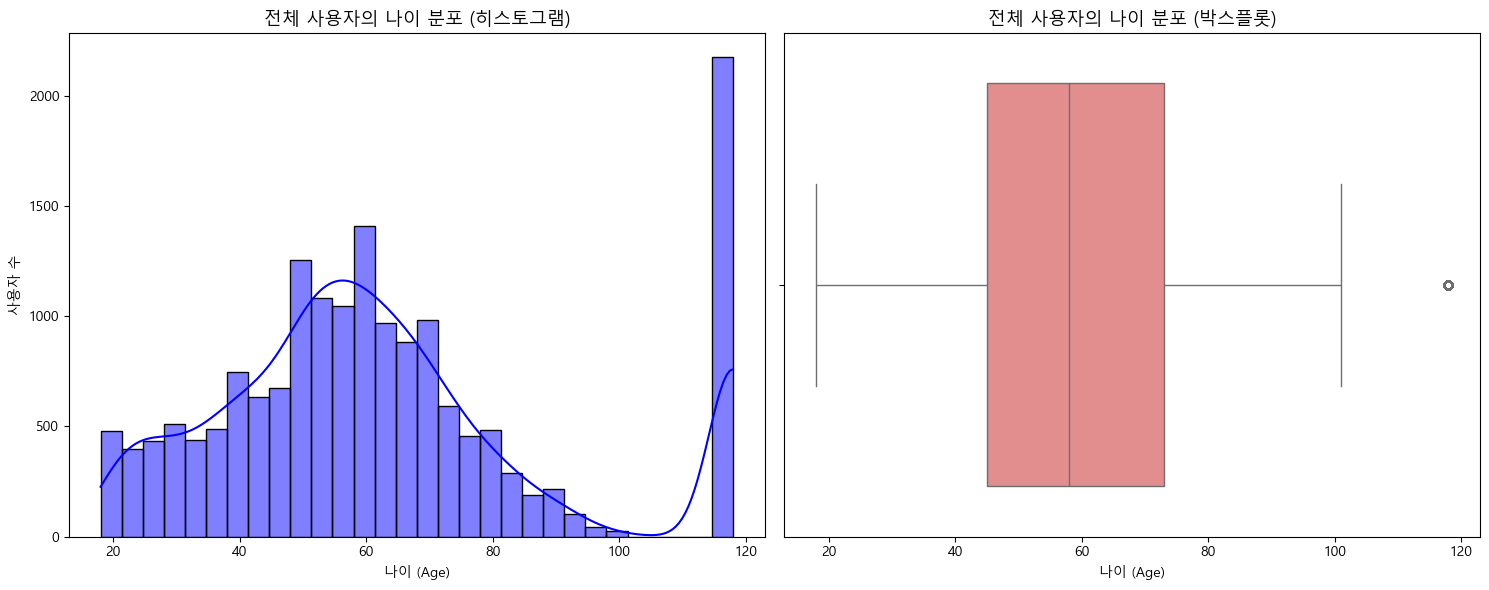

In [12]:
# age 118세 데이터 뜯어보기!

# age가 118인 데이터 행 개수
print(f"{profile[profile['age']==118].shape}") #2175

# age가 118세이면서, gender가 Null값인 행 개수
print(f"{profile[(profile['age']==118) & (profile['gender'].isna())].shape}") #2175

# age가 118세이면서, income이 Null값인 행 개수
print(f"{profile[(profile['age']==118) & (profile['income'].isna())].shape}") #2175

# age가 118세이면서, gender, income이 Null값인 행 개수
print(f"{profile[(profile['age']==118) & (profile['income'].isna()) & (profile['gender'].isna())].shape}") #2175

# => age가 118세라면 gender, income은 모두 NaN

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 히스토그램
sns.histplot(profile['age'], bins=30, kde=True, color='blue', ax=axes[0])
axes[0].set_title('전체 사용자의 나이 분포 (히스토그램)', fontsize=13)
axes[0].set_xlabel('나이 (Age)')
axes[0].set_ylabel('사용자 수')

# 2. 박스플롯
sns.boxplot(x=profile['age'], color='lightcoral', ax=axes[1])
axes[1].set_title('전체 사용자의 나이 분포 (박스플롯)', fontsize=13)
axes[1].set_xlabel('나이 (Age)')

plt.tight_layout()
plt.show()


### age컬럼의 특징(이상한 점)
- 1. age가 118인 행이 2175개
- 2. age의 중앙값 : 58, 평균 : 62

### => 해결방법)
- 1. age가 118인 행 날리기
- 2. age가 118인 데이터 Unknown처리하기
- 3. age 컬럼 자체가 이상하다고 판단하고, age 컬럼 자체를 사용하지 않기

(212, 6)


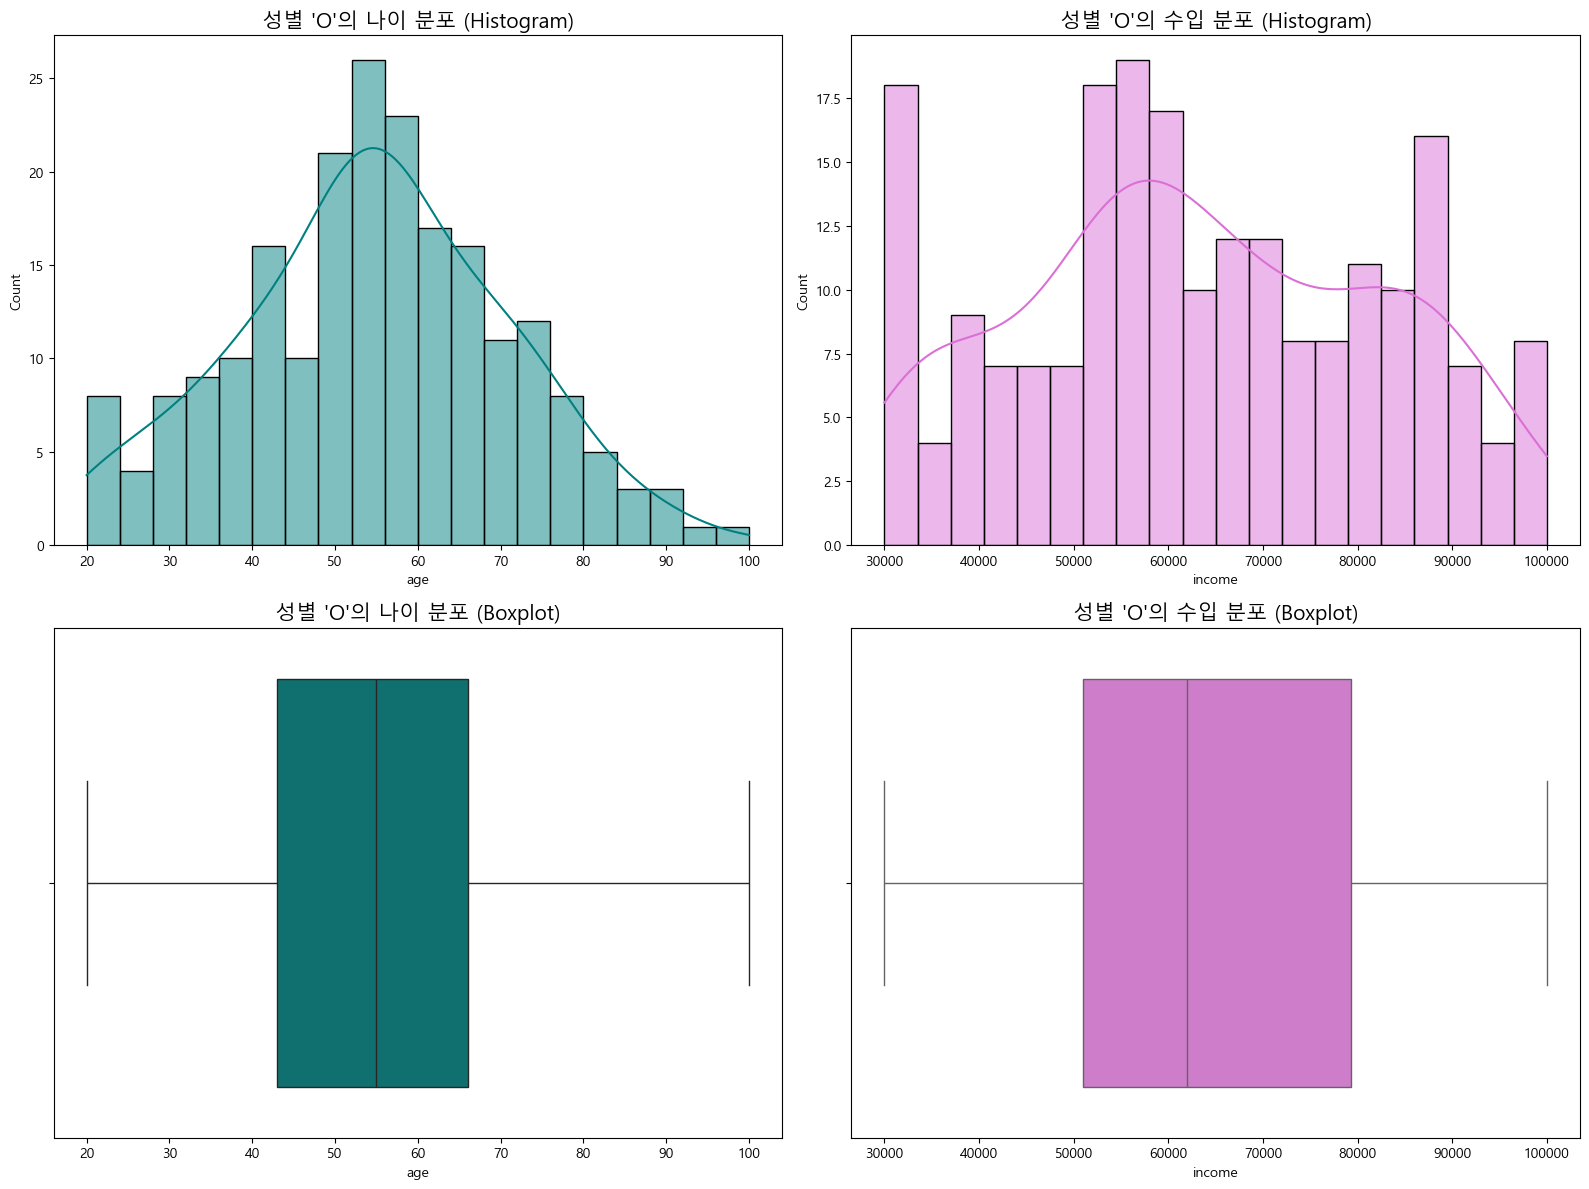

In [13]:
# gender가 'O'인 데이터 뜯어보기!

# gender가 'O'인 행의 개수
print(f"{profile[profile['gender']=='O'].shape}") # 212

gender_other = profile[profile['gender']=='O']

#시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1,1) 나이 히스토그램
sns.histplot(gender_other['age'], bins=20, kde=True, color='teal', ax=axes[0, 0])
axes[0, 0].set_title("성별 'O'의 나이 분포 (Histogram)", fontsize=15)

# (1,2) 수입 히스토그램
sns.histplot(gender_other['income'], bins=20, kde=True, color='orchid', ax=axes[0, 1])
axes[0, 1].set_title("성별 'O'의 수입 분포 (Histogram)", fontsize=15)

# (2,1) 나이 박스플롯
sns.boxplot(x=gender_other['age'], color='teal', ax=axes[1, 0])
axes[1, 0].set_title("성별 'O'의 나이 분포 (Boxplot)", fontsize=15)

# (2,2) 수입 박스플롯
sns.boxplot(x=gender_other['income'], color='orchid', ax=axes[1, 1])
axes[1, 1].set_title("성별 'O'의 수입 분포 (Boxplot)", fontsize=15)

plt.tight_layout()
plt.show()

# 문제 없어 보인다.

### gender 컬럼의 특징
- 1. 'M', 'F'를 제외한 'O'가 212개 존재함
### 해결방법)
- 1. 'O'를 Unknown으로 둔다.
- 2. gender가 'O'인 행을 drop한다.


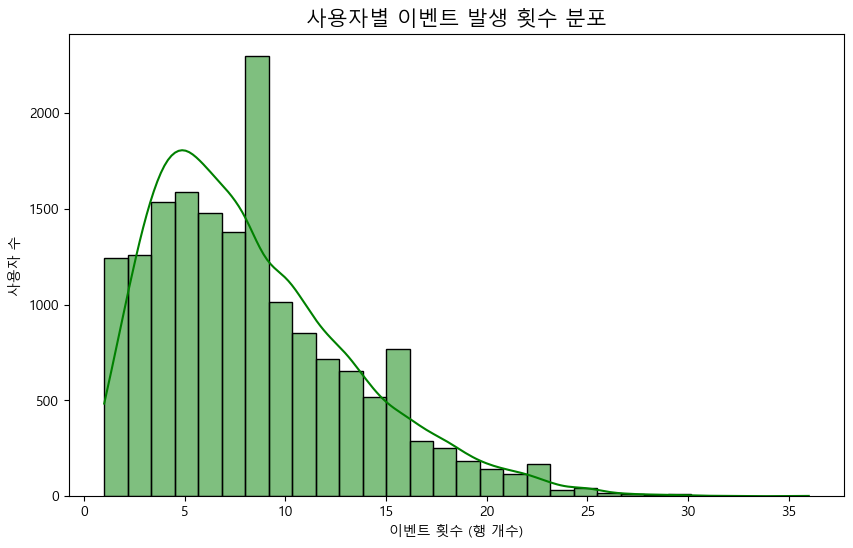

In [14]:
# 사용자별 이벤트 발생 횟수 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(transaction['person'].value_counts(), bins=30, kde=True, color='green')
plt.title('사용자별 이벤트 발생 횟수 분포', fontsize=15)
plt.xlabel('이벤트 횟수 (행 개수)')
plt.ylabel('사용자 수')
plt.show()

In [15]:
transcript[transcript['event'] == 'offer received']

,Unnamed: 0,person,event,value,time,amount,offer_id,reward
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN
...,...,...,...,...,...,...,...,...
257882,257882,d087c473b4d247ccb0abfef59ba12b0e,offer received,{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'},576,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN
257883,257883,cb23b66c56f64b109d673d5e56574529,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},576,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
257884,257884,6d5f3a774f3d4714ab0c092238f3a1d7,offer received,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},576,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
257885,257885,9dc1421481194dcd9400aec7c9ae6366,offer received,{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'},576,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN


## event 가설
- offer recieved : 고객이 프로모션을 수신 -> 즉, 고객의 어플 내에 쿠폰이 들어온 시점
- offer viewed : 고객이 프로모션을 조회 -> 즉, 고객이 어플 내 쿠폰함에 들어가서 쿠폰을 확인한 시점
- transaction : 고객이 제품을 구매
- offer completed : 고객이 프로모션의 조건을 충족해서 리워드를 받는 상태

### 이상적 데이터 흐름
- offer received -> offer viewed -> transaction -> offer completed
- offer received -> transaction -> offer completed
- offer received -> offer viewed -> transaction
- offer received -> transaction
- offer received -> offer viewed
- offer received
- transaction -> transaction -> transaction -> ....

### 이상한 데이터 흐름
- offer viewed -> offer received : 순서역전
- transaction 없는 completed 
- 동일 time에 발생하는 이벤트 (단, transaction -> offer completed는 정상으로 본다.)

In [16]:
transcript[transcript['person']=='0020c2b971eb4e9188eac86d93036a77']

,Unnamed: 0,person,event,value,time,amount,offer_id,reward
1889,1889,0020c2b971eb4e9188eac86d93036a77,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
18431,18431,0020c2b971eb4e9188eac86d93036a77,offer viewed,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},12,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
31326,31326,0020c2b971eb4e9188eac86d93036a77,transaction,{'amount': 17.63},54,17.63,NaN,NaN
31327,31327,0020c2b971eb4e9188eac86d93036a77,offer completed,"{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4', 'reward': 2}",54,NaN,fafdcd668e3743c1bb461111dcafc2a4,2.0
34287,34287,0020c2b971eb4e9188eac86d93036a77,transaction,{'amount': 32.0},66,32.00,NaN,NaN
35751,35751,0020c2b971eb4e9188eac86d93036a77,transaction,{'amount': 24.39},72,24.39,NaN,NaN
49660,49660,0020c2b971eb4e9188eac86d93036a77,transaction,{'amount': 24.31},144,24.31,NaN,NaN
55085,55085,0020c2b971eb4e9188eac86d93036a77,offer received,{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'},168,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN
112698,112698,0020c2b971eb4e9188eac86d93036a77,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},336,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
152505,152505,0020c2b971eb4e9188eac86d93036a77,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},408,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN


In [ ]:
transcript_sorted = transcript.sort_values(by=['person','time'])

user_event_flow = transcript_sorted.groupby('person')['event'].apply(lambda x: ' -> '.join(x)).reset_index()
user_event_flow.columns = ['person', 'event_flow']
user_event_flow

,person,event_flow
0,0009655768c64bdeb2e877511632db8f,offer received -> offer viewed -> transaction -> offer received -> offer viewed -> offer received -> transaction -> offer completed -> offer viewed -> offer received -> transaction -> offer completed -> offer viewed -> transaction -> offer received -> transaction -> offer completed -> transaction -> transaction -> transaction
1,00116118485d4dfda04fdbaba9a87b5c,offer received -> offer viewed -> transaction -> transaction -> transaction -> offer received -> offer viewed
2,0011e0d4e6b944f998e987f904e8c1e5,offer received -> offer viewed -> transaction -> offer received -> offer viewed -> transaction -> offer completed -> offer received -> offer viewed -> offer received -> offer viewed -> offer received -> offer viewed -> transaction -> offer completed -> offer completed -> transaction -> transaction
3,0020c2b971eb4e9188eac86d93036a77,offer received -> offer viewed -> transaction -> offer completed -> transaction -> transaction -> transaction -> offer received -> offer received -> offer received -> offer viewed -> offer received -> transaction -> offer completed -> offer completed -> transaction -> offer viewed -> transaction -> transaction
4,0020ccbbb6d84e358d3414a3ff76cffd,transaction -> offer received -> offer viewed -> transaction -> offer completed -> transaction -> transaction -> transaction -> offer received -> offer viewed -> transaction -> offer completed -> offer received -> offer viewed -> transaction -> transaction -> transaction -> transaction -> offer received -> offer viewed -> transaction -> offer completed -> transaction
...,...,...
16995,fff3ba4757bd42088c044ca26d73817a,offer received -> offer viewed -> transaction -> offer completed -> transaction -> transaction -> transaction -> offer received -> transaction -> offer completed -> transaction -> offer viewed -> transaction -> transaction -> offer received -> offer received -> offer received -> transaction -> offer completed -> offer viewed -> transaction -> transaction -> offer received
16996,fff7576017104bcc8677a8d63322b5e1,offer received -> offer viewed -> transaction -> offer received -> offer viewed -> transaction -> offer completed -> transaction -> offer received -> offer viewed -> offer received -> offer viewed -> transaction -> offer received -> transaction -> offer completed -> offer completed -> transaction
16997,fff8957ea8b240a6b5e634b6ee8eafcf,transaction -> transaction -> offer received -> offer viewed -> transaction -> transaction -> offer received -> offer received -> transaction -> offer viewed
16998,fffad4f4828548d1b5583907f2e9906b,offer received -> offer viewed -> transaction -> offer completed -> transaction -> transaction -> transaction -> offer received -> offer viewed -> transaction -> transaction -> transaction -> transaction -> offer received -> offer viewed -> transaction -> offer completed -> transaction -> offer received -> transaction -> offer completed -> offer viewed -> transaction


In [ ]:
#time_diff가 0인 이벤트들
transcript_sorted['prev_person'] = transcript_sorted['person'].shift(1)
transcript_sorted['prev_event'] = transcript_sorted['event'].shift(1)
transcript_sorted['prev_time'] = transcript_sorted['time'].shift(1)

duplicate_events = transcript_sorted[
    (transcript_sorted['person'] == transcript_sorted['prev_person']) & 
    (transcript_sorted['time'] == transcript_sorted['prev_time'])
]
duplicate_events['time_diff'] = duplicate_events['time'] - duplicate_events['prev_time']
duplicate_events[['person', 'event', 'prev_event', 'time', 'prev_time', 'time_diff']].head(30)

,person,event,prev_event,time,prev_time,time_diff
168413,0009655768c64bdeb2e877511632db8f,offer completed,transaction,414,414.0,0.0
228423,0009655768c64bdeb2e877511632db8f,offer completed,transaction,528,528.0,0.0
258883,0009655768c64bdeb2e877511632db8f,transaction,offer received,576,576.0,0.0
258884,0009655768c64bdeb2e877511632db8f,offer completed,transaction,576,576.0,0.0
95422,0011e0d4e6b944f998e987f904e8c1e5,offer completed,transaction,252,252.0,0.0
258980,0011e0d4e6b944f998e987f904e8c1e5,offer completed,transaction,576,576.0,0.0
258981,0011e0d4e6b944f998e987f904e8c1e5,offer completed,offer completed,576,576.0,0.0
31327,0020c2b971eb4e9188eac86d93036a77,offer completed,transaction,54,54.0,0.0
218936,0020c2b971eb4e9188eac86d93036a77,offer completed,transaction,510,510.0,0.0
218937,0020c2b971eb4e9188eac86d93036a77,offer completed,offer completed,510,510.0,0.0


In [29]:
duplicate_events = transcript_sorted[
    (transcript_sorted['person'] == transcript_sorted['prev_person']) & 
    (transcript_sorted['time'] == transcript_sorted['prev_time'] ) &
    (transcript_sorted['event'] == transcript_sorted['prev_event'])
]
duplicate_events['time_diff'] = duplicate_events['time'] - duplicate_events['prev_time']
display(duplicate_events[['person', 'event', 'prev_event', 'time', 'prev_time', 'time_diff']].sort_values(by=['event', 'prev_event']).head())
display(duplicate_events[['person', 'event', 'prev_event', 'time', 'prev_time', 'time_diff']].sort_values(by=['event', 'prev_event']).tail())


,person,event,prev_event,time,prev_time,time_diff
258981,0011e0d4e6b944f998e987f904e8c1e5,offer completed,offer completed,576,576.0,0.0
218937,0020c2b971eb4e9188eac86d93036a77,offer completed,offer completed,510,510.0,0.0
281777,00ae03011f9f49b8a4b3e6d416678b0b,offer completed,offer completed,618,618.0,0.0
263989,00c2f812f4604c8893152a5c6572030e,offer completed,offer completed,582,582.0,0.0
242917,00cf1bbec83f4a658f8994e556db4633,offer completed,offer completed,564,564.0,0.0


,person,event,prev_event,time,prev_time,time_diff
216982,ffda4545e7084ff6aaf01304fb1c1fa6,offer completed,offer completed,504,504.0,0.0
86339,ffe5257abf8840b395e1ee6b29894637,offer completed,offer completed,216,216.0,0.0
68854,fff29fb549084123bd046dbc5ceb4faa,offer completed,offer completed,168,168.0,0.0
176860,fff29fb549084123bd046dbc5ceb4faa,offer completed,offer completed,426,426.0,0.0
269952,fff7576017104bcc8677a8d63322b5e1,offer completed,offer completed,594,594.0,0.0
